### Frequency Domain representation of real and complex signals, for both positive and negative frequencies.

In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import scipy.fft as spfft

In [2]:
# Interactive plotting.  Comment out this next line if inline plots are desired.
#%matplotlib qt

In [3]:
# Function to create IQ representation of sine wave at a given freq for a given sample rate.
#
# Inputs: 
#  freq - frequency of sine wave, Hz
#  amp  - amplitude, arbitrary units
#  fs   - sampling rate of sine wave, Hz
#  no_samps - number of samples to generate
#
# Returns:
#  complex (IQ) representation of sine wave with input parameters.
#
# Affects: None
#
# Exceptions: AssertionError if freq >= fs.
#
def create_sig(freq, amp, fs, no_samps):
    assert freq < fs
    delta_t = 1.0 / fs
    x = np.linspace(0.0, no_samps * delta_t, no_samps, endpoint=False)
    iq = amp * np.exp(1j * freq * 2.0 * np.pi * x)
    return iq

In [4]:
# Function to plot the frequency domain spectrum of a complex signal.
#
# Inputs: 
#  y - complex time domain signal to be plotted
#  fs - sampling rate, Hz
#  ttext - title of plot
#
# Returns:
#  Plot of frequency domain representation of signal.
#
# Affects: None
#
# Exceptions: None
#
def spec_plot(y, fs, ttext):
    delta_t = 1.0 / fs
    no_samps = len(y)
    yf = spfft.fft(y)
    xf = spfft.fftfreq(no_samps, delta_t)
    xf_shift = spfft.fftshift(xf)
    yf_shift = spfft.fftshift(yf)
    plt.figure()
    plt.plot(xf_shift, 1.0/no_samps * np.abs(yf_shift))
    plt.xlabel('Frequency, Hz')
    plt.ylabel('Spectral amplitude')
    plt.title(ttext)
    plt.grid()
    plt.show()

In [5]:
# Set general signal parameters
fs = 32000  # sample rate
cf = 10000  # center frequency (used in baseband shift)
sig_4_f = 12000  # frequency of signal, Hz
sig_4_a = 1.0    # amplitude
no_samps = 32000 # number of samples

In [6]:
# Shift to baseband, creating a signal at 2000 Hz
freq = sig_4_f - cf
amp = sig_4_a

In [7]:
# create cos time series (real signal)
delta_t = 1.0 / fs
x = np.linspace(0.0, no_samps * delta_t, no_samps, endpoint=False)
cos_time_series = amp * np.cos(freq * 2.0 * np.pi * x)

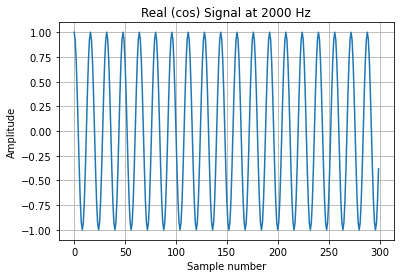

In [8]:
# plot first 300 samples of signal
plt.figure()
plt.plot(cos_time_series[0:300])
plt.grid()
plt.xlabel('Sample number')
plt.ylabel('Amplitude')
plt.title('Real (cos) Signal at 2000 Hz')
plt.show()

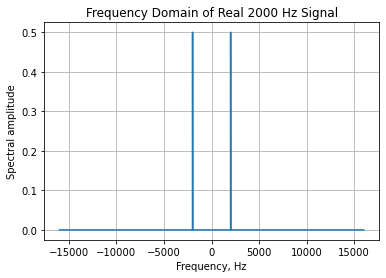

In [9]:
# plot the frequency domain representation of this signal
spec_plot(cos_time_series, fs, 'Frequency Domain of Real 2000 Hz Signal')

In [10]:
# create a complex IQ signal with positive frequency
pos_freq_iq = create_sig(freq, amp, fs, no_samps)

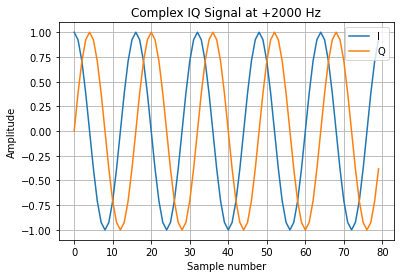

In [17]:
# plot first 300 samples of this signal, showing both I and Q components
plt.figure()
plt.plot(np.real(pos_freq_iq[0:80]), label='I')
plt.plot(np.imag(pos_freq_iq[0:80]), label='Q')
plt.grid()
plt.legend()
plt.xlabel('Sample number')
plt.ylabel('Amplitude')
plt.title('Complex IQ Signal at +2000 Hz')
plt.show()

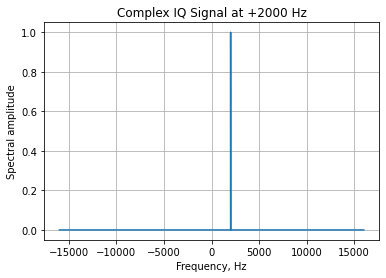

In [12]:
# plot the frequency domain representation of the positive freq complex signal
spec_plot(pos_freq_iq, fs, 'Complex IQ Signal at +2000 Hz')

In [13]:
# create a complex IQ signal with negative frequency
neg_freq_iq = create_sig(-freq, amp, fs, no_samps)

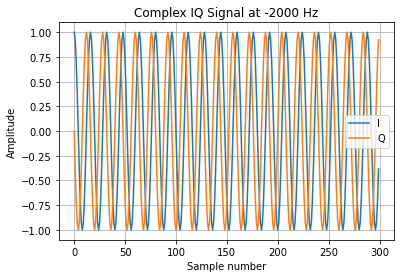

In [14]:
# plot first 300 samples of this signal, showing both I and Q components
plt.figure()
plt.plot(np.real(neg_freq_iq[0:300]),label='I')
plt.plot(np.imag(neg_freq_iq[0:300]),label='Q')
plt.grid()
plt.legend()
plt.xlabel('Sample number')
plt.ylabel('Amplitude')
plt.title('Complex IQ Signal at -2000 Hz')
plt.show()

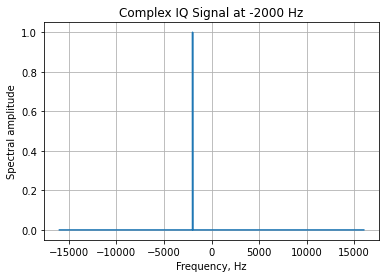

In [15]:
# plot the frequency domain representation of the negative freq complex signal
spec_plot(neg_freq_iq, fs, 'Complex IQ Signal at -2000 Hz')